<a href="https://colab.research.google.com/github/SauSauN/Data_Nelly_Academic_Project/blob/main/KmeansClustering_VStd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### KMeans Clustering

https://www.kaggle.com/rammilan2612/driver-data

The Variables used are:
* Driver_ID
* Distance_Feature
* Speeding_Feature

In [222]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### Load and read dataset

In [223]:
#load and read the first 10 samples
df = pd.read_csv('/content/Driver_data.csv')
df.head(10)

,Driver_ID,Distance_Feature,Speeding_Feature
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
5,3423313857,41.91,10
6,3423312432,58.64,20
7,3423311434,52.02,8
8,3423311328,31.25,34
9,3423312488,44.31,19


In [224]:
#print the shape
df.shape

(4000, 3)

In [225]:
#print the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Driver_ID         4000 non-null   int64  
 1   Distance_Feature  4000 non-null   float64
 2   Speeding_Feature  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [226]:
#count the null values
df.isnull().sum()

,0
Driver_ID,0
Distance_Feature,0
Speeding_Feature,0


In [227]:
#print the exploratory statistics
df.describe()

,Driver_ID,Distance_Feature,Speeding_Feature
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


In [228]:
#feature selection
driver_data = df[['Distance_Feature', 'Speeding_Feature']]


#print the head of your dataframe
driver_data.head()

,Distance_Feature,Speeding_Feature
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


<Axes: xlabel='Distance_Feature', ylabel='Speeding_Feature'>

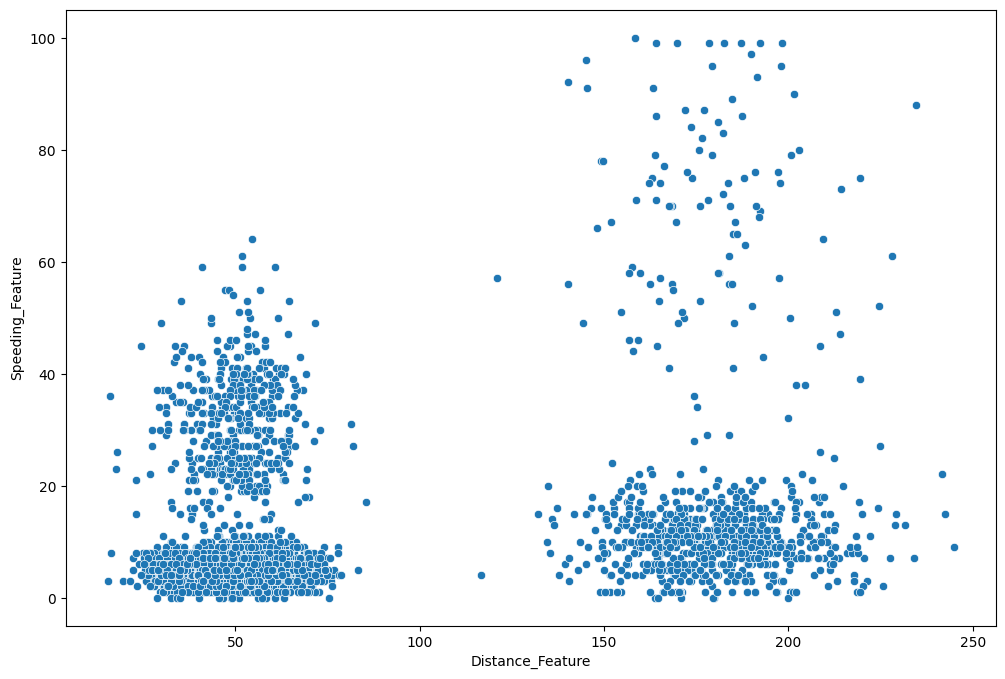

In [229]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='Distance_Feature',
    y='Speeding_Feature',
    data=driver_data
)

<Figure size 1200x800 with 0 Axes>

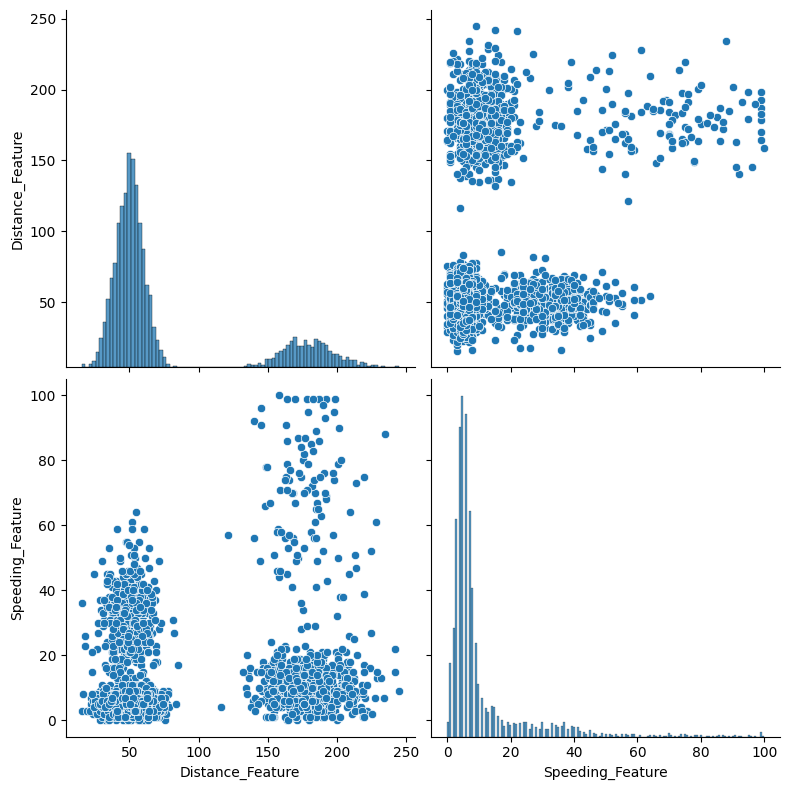

In [230]:
plt.figure(figsize = [12, 8])

sns.pairplot(driver_data, height = 4)

In [231]:
f1 = driver_data['Distance_Feature'].values

print(f1)

[ 71.24  52.53  64.54 ... 170.91 176.14 168.03]


In [232]:
f2 = driver_data['Speeding_Feature'].values

print(f2)

[28 25 27 ... 12  5  9]


In [233]:
X = np.array(list(zip(f1, f2)))

### Visualize Raw Data and initial centroids

In [234]:
k = 2

C_x = np.random.randint(0, np.max(X) - 20, size = k)
C_y = np.random.randint(0, np.max(X) - 20, size = k)

#### Plotting along with the Centroids

Text(0, 0.5, 'Speeding Feature')

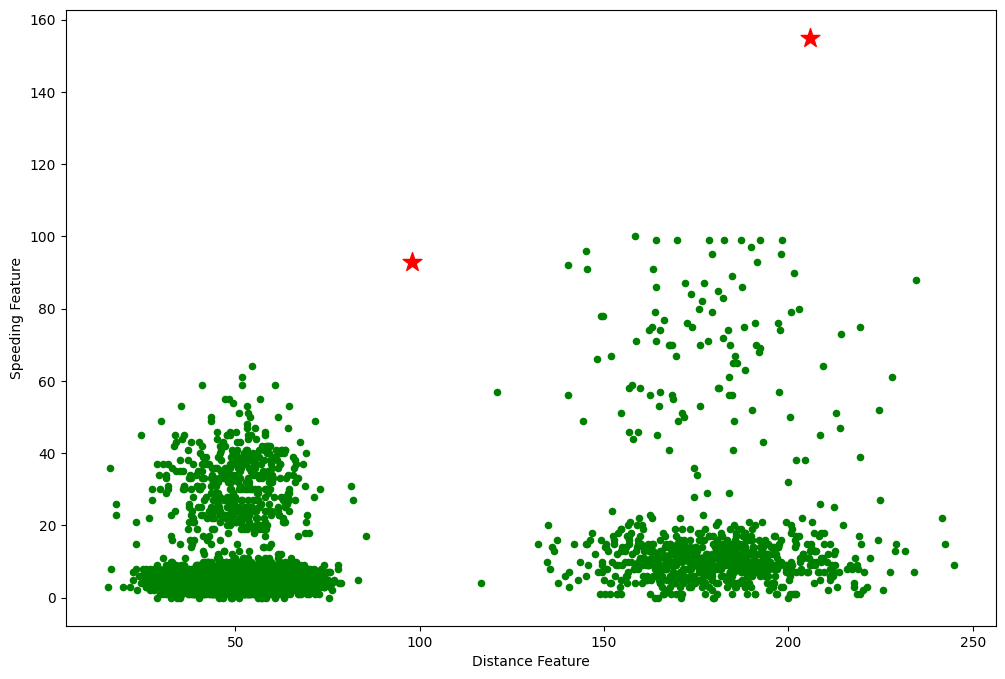

In [235]:
plt.figure(figsize = [12, 8])

plt.scatter(f1, f2, c = 'g', s = 20)

plt.scatter(C_x, C_y, marker = '*',
            c = 'r', s = 200)


plt.xlabel('Distance Feature')
plt.ylabel('Speeding Feature')

### Kmeans Model

#### K = 2

In [264]:
from sklearn.cluster import KMeans

#create kmeans model (kmeans_2) with k=2 and fit it on your data

# création du modèle k-means avec k = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42, max_iter=100)

driver_data_2 = driver_data.copy()


# entraînement sur tes données
kmeans_2.fit(driver_data)


# Prédictions (cluster de chaque point)
labels_2 = kmeans_2.labels_

# Centres des clusters
centroids_2 = kmeans_2.cluster_centers_



In [265]:
#print the labels generated by the model
print("Labels :", labels_2)

Labels : [0 0 0 ... 1 1 1]


In [238]:
#print the centroids
print("Centres :", centroids_2)


Centres : [[ 50.04763437   8.82875   ]
 [180.017075    18.29      ]]


In [239]:
#print the first 10 samples in order to do first observations on the clustering
driver_data_2[:10]

,Distance_Feature,Speeding_Feature
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25
5,41.91,10
6,58.64,20
7,52.02,8
8,31.25,34
9,44.31,19


In [266]:
print(driver_data_2.columns)

driver_data_2['kmeans_2_labels'] = kmeans_2.labels_

print(driver_data_2.columns)


Index(['Distance_Feature', 'Speeding_Feature'], dtype='object')
Index(['Distance_Feature', 'Speeding_Feature', 'kmeans_2_labels'], dtype='object')


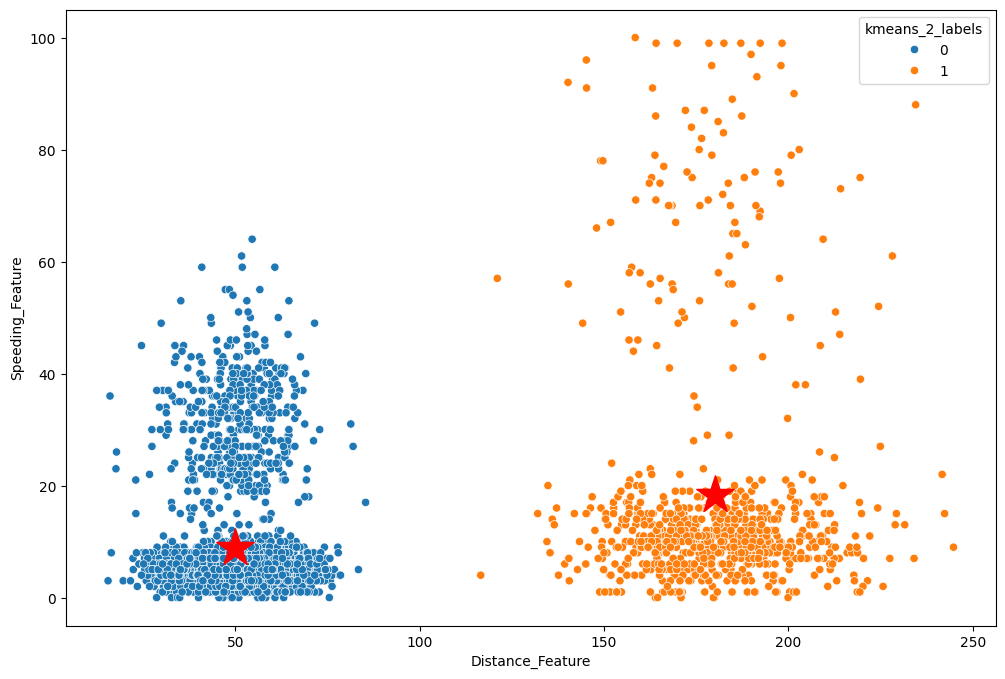

In [241]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='Distance_Feature',
    y='Speeding_Feature',
    data=driver_data_2,
    hue='kmeans_2_labels'
)

plt.scatter(centroids_2[:, 0], centroids_2[:, 1],
            marker = '*', s = 800, c =  'r')

#### K = 4

In [258]:
#create kmeans model (kmeans_4) with k=4 and fit it on your data

# création du modèle k-means avec k = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42, max_iter=100)

driver_data_4 = driver_data.copy()


# entraînement sur tes données
kmeans_4.fit(driver_data_4)


# Prédictions (cluster de chaque point)
labels_4 = kmeans_4.labels_

# Centres des clusters
centroids_4 = kmeans_4.cluster_centers_



In [259]:
#print the labels generated by the model
print("Labels :", labels_4)

Labels : [2 2 2 ... 1 1 1]


In [260]:
#print the centroids
print("Centres :", centroids_4)

Centres : [[ 49.98428468   5.21441441]
 [180.34311782  10.52011494]
 [ 50.46127059  32.42823529]
 [177.83509615  70.28846154]]


In [261]:
#print the first 10 samples in order to do first observations on the clustering
driver_data_4[:10]

,Distance_Feature,Speeding_Feature
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25
5,41.91,10
6,58.64,20
7,52.02,8
8,31.25,34
9,44.31,19


In [262]:
print(driver_data_4.columns)

driver_data_4['kmeans_4_labels'] = kmeans_4.labels_

print(driver_data_4.columns)


Index(['Distance_Feature', 'Speeding_Feature'], dtype='object')
Index(['Distance_Feature', 'Speeding_Feature', 'kmeans_4_labels'], dtype='object')


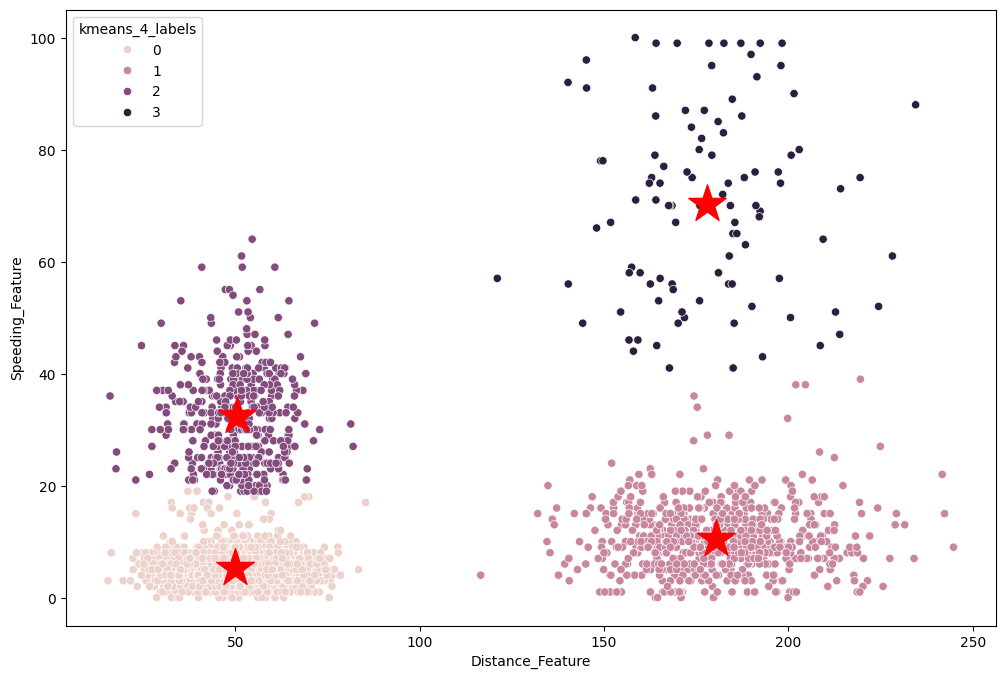

In [263]:
plt.figure(figsize = [12, 8])

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',
                data=driver_data_4,
                hue='kmeans_4_labels')

plt.scatter(centroids_4[:, 0], centroids_4[:, 1],
            marker = '*', s = 800, c =  'r')

#### K = 6

In [267]:
#create kmeans model (kmeans_6) with k=6 and fit it on your data

# création du modèle k-means avec k = 6
kmeans_6 = KMeans(n_clusters=6, random_state=42, max_iter=100)

driver_data_6 = driver_data.copy()

# entraînement sur tes données
kmeans_6.fit(driver_data_6)


# Prédictions (cluster de chaque point)
labels_6 = kmeans_6.labels_

# Centres des clusters
centroids_6 = kmeans_6.cluster_centers_




In [249]:
#print the labels generated by the model
print("Labels :", labels_6)

Labels : [5 5 5 ... 1 1 1]


In [250]:
#print the centroids
print("Centres :", centroids_6)

Centres : [[ 57.85701936   5.28215768]
 [166.49554974  10.42408377]
 [ 41.52009623   5.39600296]
 [197.25805643  11.18495298]
 [176.63676768  71.53535354]
 [ 50.61421836  33.06203474]]


In [251]:
print(driver_data_6.columns)

driver_data_6['kmeans_6_labels'] = kmeans_6.labels_

print(driver_data_6.columns)


Index(['Distance_Feature', 'Speeding_Feature'], dtype='object')
Index(['Distance_Feature', 'Speeding_Feature', 'kmeans_6_labels'], dtype='object')


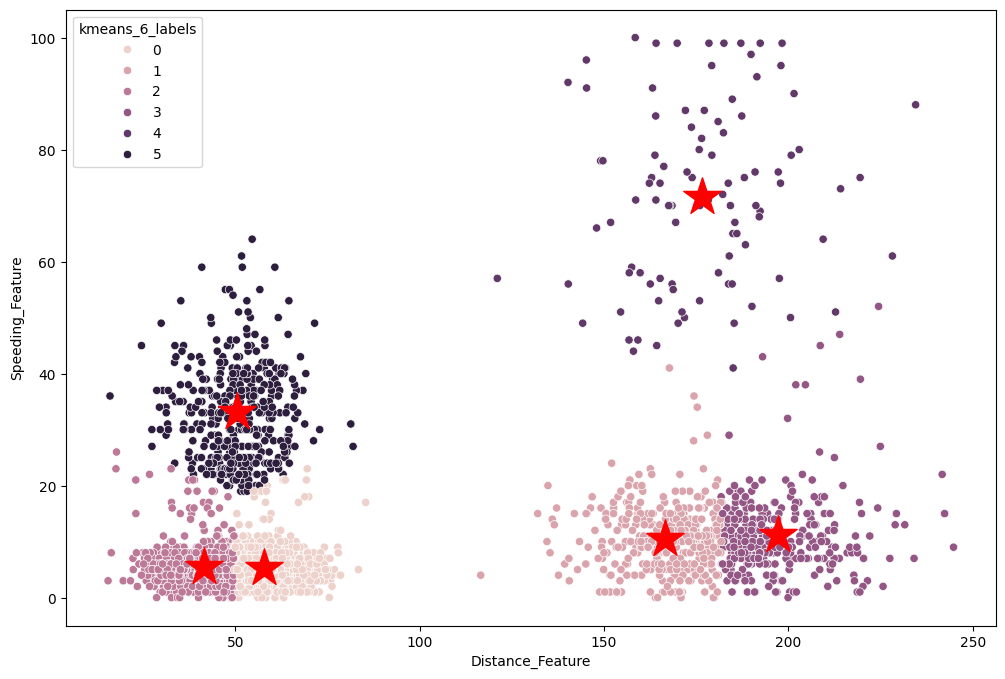

In [252]:
plt.figure(figsize = [12, 8])

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',
                data=driver_data_6,
                hue='kmeans_6_labels')

plt.scatter(centroids_6[:, 0], centroids_6[:, 1],
            marker = '*', s = 800, c =  'r')

### Evaluation

In [253]:
from sklearn import metrics

from sklearn.metrics import silhouette_score

In [254]:
# print ss_2 : the silhouette_score of the model kmeans_2
ss_2 = silhouette_score(
    driver_data_2[['Distance_Feature', 'Speeding_Feature']],
    driver_data_2['kmeans_2_labels']
)

print(ss_2)

0.8490223286225532


In [255]:
# print ss_4 : the silhouette_score of the model kmeans_4

ss_4 = silhouette_score(
    driver_data_4[['Distance_Feature', 'Speeding_Feature']],
    driver_data_4['kmeans_4_labels']
)

print(ss_4)


0.42288828244753307


In [256]:
# print ss_6 : the silhouette_score of the model kmeans_6

ss_6 = silhouette_score(
    driver_data_6[['Distance_Feature', 'Speeding_Feature']],
    driver_data_6['kmeans_6_labels']
)

print(ss_6)


0.4856010614331868


In [257]:
# write your insights
